In [1]:
import xgboost as xgb
from xgboost import plot_importance, plot_tree, plotting

import dtreeviz
import graphviz
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams

import pandas as pd
import numpy as np

random_state = 636

## Load dataset

In [2]:
dataset_path = "../processed.cleveland.data.csv"

df = pd.read_csv(dataset_path)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## Fit xgboost

In [3]:
features = [c for c in df.columns if c != 'target']
target = "target"

dtrain = xgb.DMatrix(df[features], df[target])

params = {"max_depth":3, "eta":1, "objective":"binary:logistic", "subsample":1}

xgb_model = xgb.train(params=params, dtrain=dtrain, num_boost_round=3)

## Visualize tree 1

In [4]:
viz_tr1 = dtreeviz.model(xgb_model, tree_index=0,
                           X_train=df[features], y_train=df[target],
                           feature_names=features,
                           target_name=target, class_names=["normal", "heart disease"])

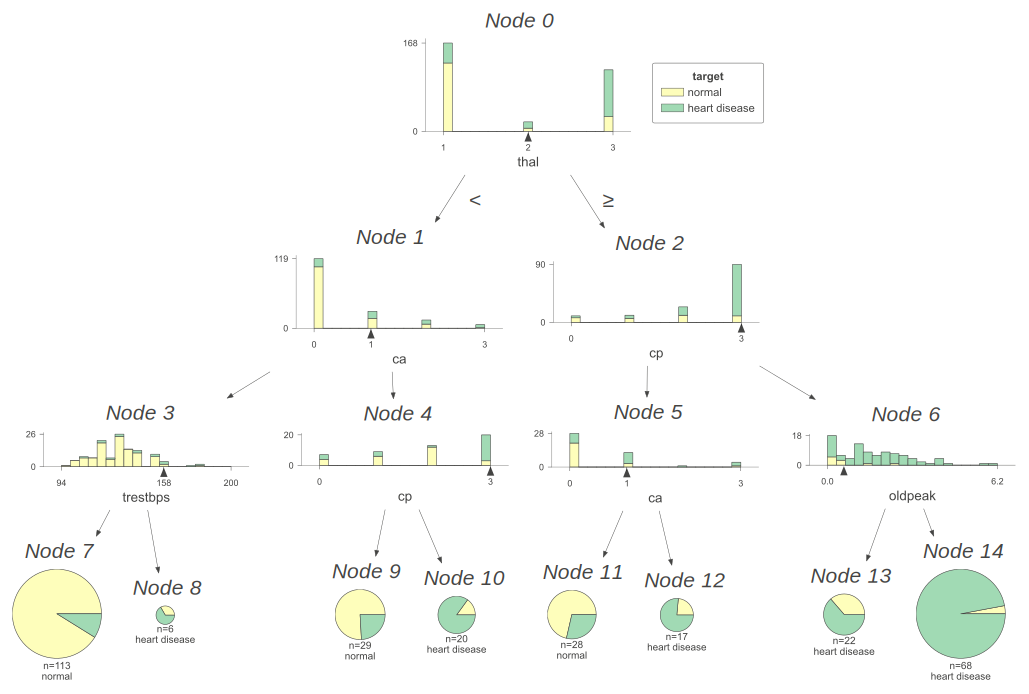

In [5]:
viz_tr1.view(show_node_labels=True, scale=1.5)

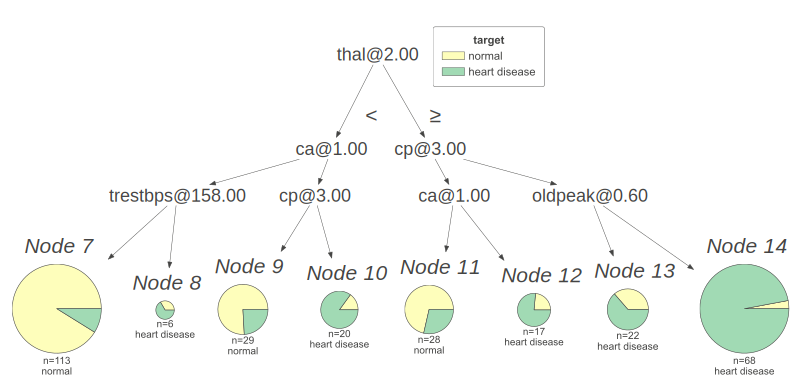

In [6]:
viz_tr1.view(fancy=False, show_node_labels=True, scale=1.5)

In [7]:
viz_tr1.shadow_tree._get_tree_dataframe()

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,thal,2.0,0-1,0-2,0-2,79.953384,75.234322,NaN
1,0,1,0-1,ca,1.0,0-3,0-4,0-4,18.376308,41.714081,NaN
2,0,2,0-2,cp,3.0,0-5,0-6,0-6,19.984879,33.520241,NaN
3,0,3,0-3,trestbps,158.0,0-7,0-8,0-8,6.929287,29.547474,NaN
4,0,4,0-4,cp,3.0,0-9,0-10,0-10,14.933178,12.166607,NaN
5,0,5,0-5,ca,1.0,0-11,0-12,0-12,8.122907,11.173414,NaN
6,0,6,0-6,oldpeak,0.6,0-13,0-14,0-14,5.906364,22.346829,NaN
7,0,7,0-7,Leaf,NaN,NaN,NaN,NaN,-1.439836,28.057684,NaN
8,0,8,0-8,Leaf,NaN,NaN,NaN,NaN,0.501056,1.489789,NaN
9,0,9,0-9,Leaf,NaN,NaN,NaN,NaN,-0.768675,7.200644,NaN


### Highlight active path with a sample input

In [8]:
# Sample input

x = df[features].iloc[0]
x

age          63.0
sex           1.0
cp            0.0
trestbps    145.0
chol        233.0
fbs           1.0
restecg       2.0
thalach     150.0
exang         0.0
oldpeak       2.3
slope         2.0
ca            0.0
thal          2.0
Name: 0, dtype: float64

C:\Users\ardih\Study\City_St_George\SMM636_Machine_Learning\SMM636-ML-group-coursework-01-g01\.venv\Lib\site-packages\dtreeviz\models\shadow_decision_tree.py:335: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\ardih\Study\City_St_George\SMM636_Machine_Learning\SMM636-ML-group-coursework-01-g01\.venv\Lib\site-packages\dtreeviz\trees.py:748: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\ardih\Study\City_St_George\SMM636_Machine_Learning\SMM636-ML-group-coursework-01-g01\.venv\Lib\site-packages\dtreeviz\trees.py:1671: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future ve

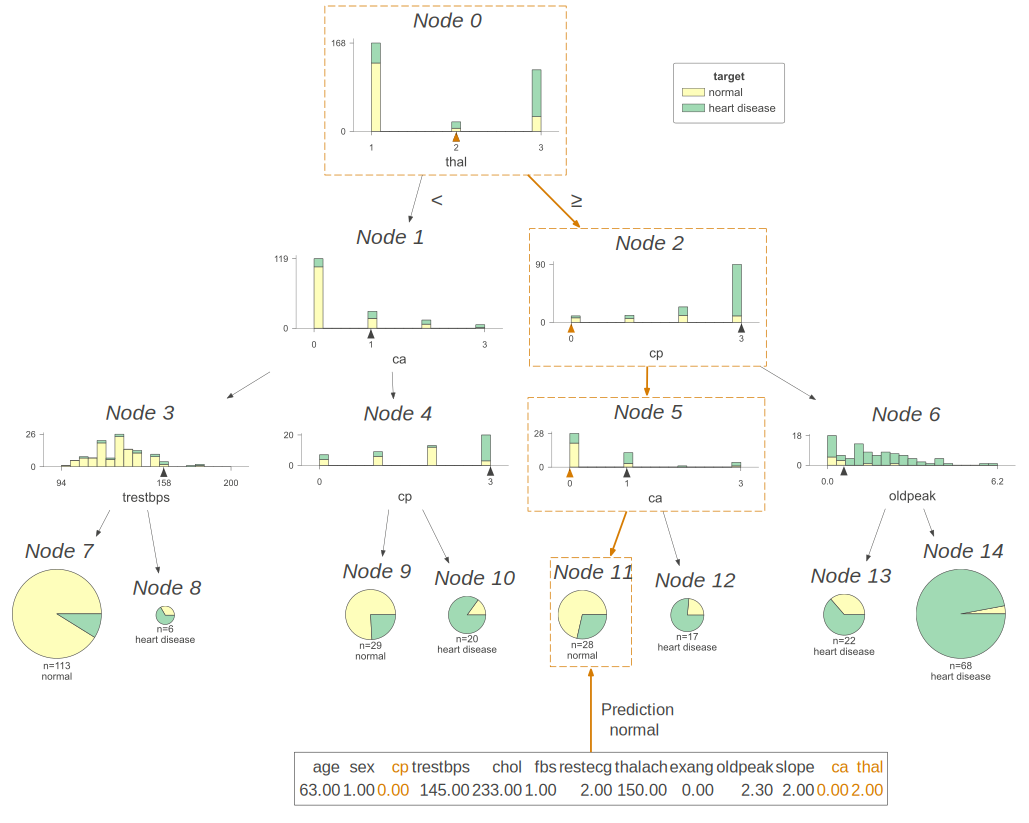

In [9]:
viz_tr1.view(x=x, show_node_labels=True, scale=1.5)

### Get path manually

In [10]:
from dtreeviz.models.xgb_decision_tree import ShadowXGBDTree

In [11]:
xgb_tr1 = ShadowXGBDTree(xgb_model, tree_index=0,
                           X_train=df[features].iloc[:1,], y_train=df[target].iloc[0],
                           feature_names=features,
                           target_name=target, class_names=["normal", "heart disease"])

In [12]:
xgb_tr1.get_node_samples()

defaultdict(list,
            {np.float32(11.0): [0],
             np.int64(5): [0],
             np.int64(2): [0],
             np.int64(0): [0]})

In [13]:
xgb_model[0].predict(xgb.DMatrix(df[features].iloc[:1,],
                                    feature_names=features),
                                    pred_leaf=True)

array([11.], dtype=float32)

In [14]:
xgb_tr1._get_leaf_prediction_path(11)

[11, np.int64(5), np.int64(2), np.int64(0)]

### Visualize tree step by step

C:\Users\ardih\Study\City_St_George\SMM636_Machine_Learning\SMM636-ML-group-coursework-01-g01\.venv\Lib\site-packages\dtreeviz\models\shadow_decision_tree.py:335: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\ardih\Study\City_St_George\SMM636_Machine_Learning\SMM636-ML-group-coursework-01-g01\.venv\Lib\site-packages\dtreeviz\trees.py:748: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\ardih\Study\City_St_George\SMM636_Machine_Learning\SMM636-ML-group-coursework-01-g01\.venv\Lib\site-packages\dtreeviz\trees.py:1671: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future ve

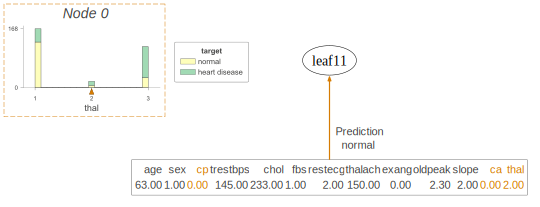

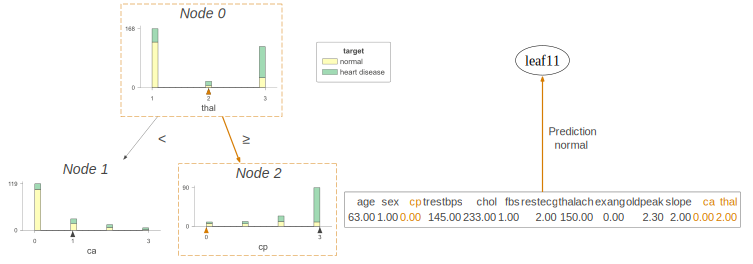

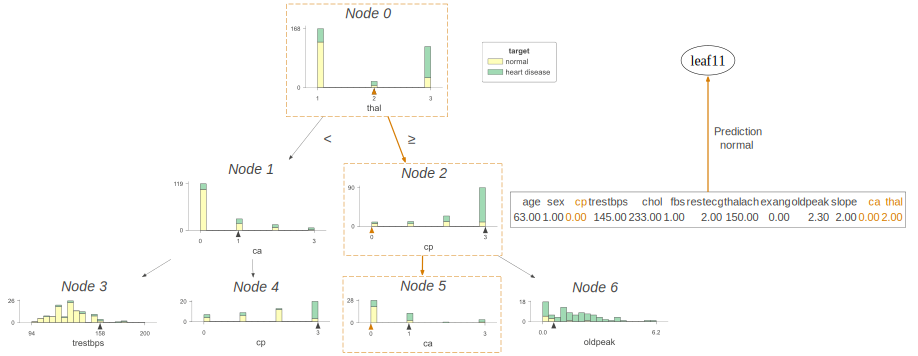

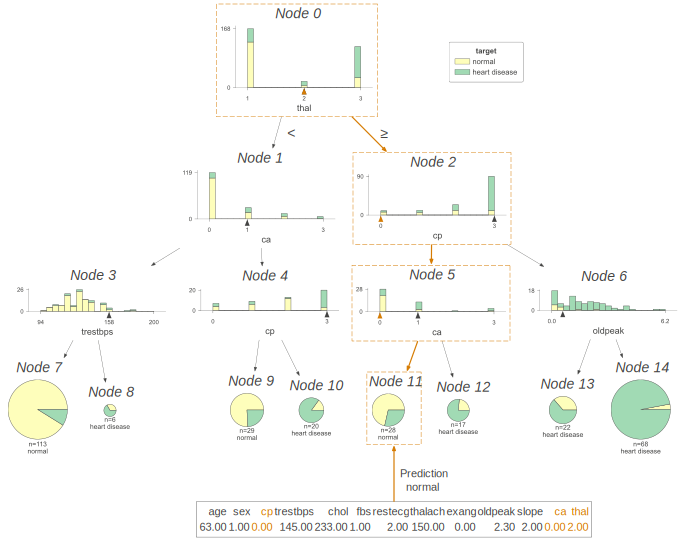

In [15]:

for i in range(3+1):
    v = viz_tr1.view(x=x,
                 show_node_labels=True,
                 depth_range_to_display=(0,i))
    display(v)


